У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [116]:
import pandas as pd
from google.colab import drive
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, precision_score, recall_score
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from imblearn.under_sampling import TomekLinks
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report


In [9]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
raw_df = pd.read_csv('drive/MyDrive/Colab Notebooks/customer_segmentation_train.csv', index_col=0) # index_col = 0 робить колонку айді індексом, оскільки у нас перша колонка айді і не несе ніякої важливості

In [14]:
target_column = 'Segmentation'
X = raw_df.drop(columns= target_column)
y = raw_df[target_column]

In [16]:
X[:5]

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
ID,,,,,,,,,
462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4
466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6


In [29]:
def checking_empty_and_type(df):
    import numpy as np

    empty_value = df.isnull().sum()
    data_type = df.dtypes

    if empty_value.any():
        print("Пропуски:")
        print(empty_value[empty_value > 0])
    else:
        print("Немає пропусків")

    print("\nТипи даних:")
    for col, dtype in data_type.items():
        if dtype == object:
            print(f"{col}: object")
        elif dtype == np.int64 or dtype == np.float64:
            print(f"{col}: числовий ({dtype})")
        else:
            print(f"{col}: інший тип — {dtype}")

    return empty_value, data_type


In [30]:
empty_value, data_type = checking_empty_and_type(X)

Пропуски:
Ever_Married       140
Graduated           78
Profession         124
Work_Experience    829
Family_Size        335
Var_1               76
dtype: int64

Типи даних:
Gender: object
Ever_Married: object
Age: числовий (int64)
Graduated: object
Profession: object
Work_Experience: числовий (float64)
Spending_Score: object
Family_Size: числовий (float64)
Var_1: object


у нас два числових стовпця, які мають нулі Family_Size та Work_Experience, проведемо аналіз цих стовпців, для визначення методу імпутації. Тобто перевіремо чи розподіл данних у нас нормальний

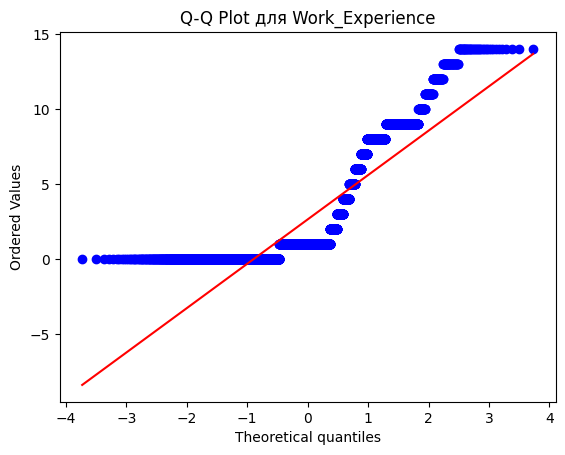

In [33]:
stats.probplot(X['Work_Experience'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot для Work_Experience")
plt.show()

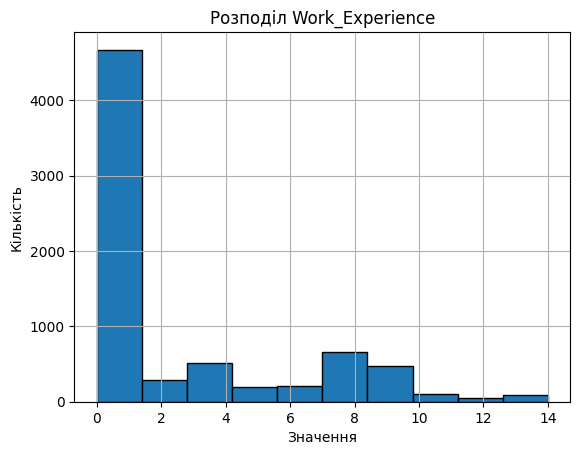

In [35]:
X['Work_Experience'].hist(bins=10, edgecolor='black')
plt.title('Розподіл Work_Experience')
plt.xlabel('Значення')
plt.ylabel('Кількість')
plt.grid(True)
plt.show()

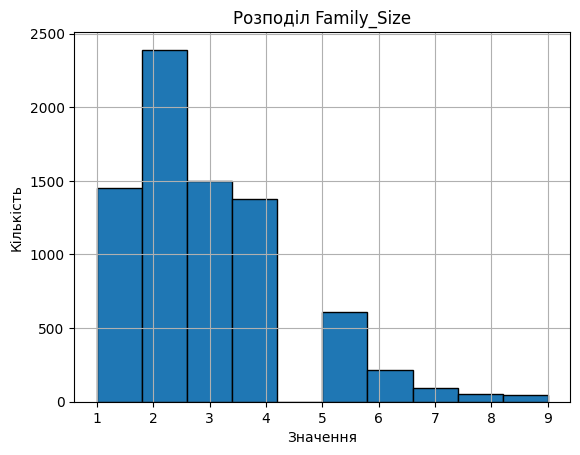

In [34]:
X['Family_Size'].hist(bins=10, edgecolor='black')
plt.title('Розподіл Family_Size')
plt.xlabel('Значення')
plt.ylabel('Кількість')
plt.grid(True)
plt.show()


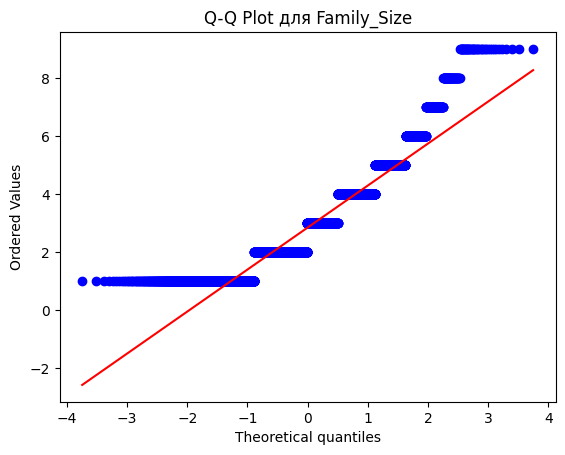

In [36]:
stats.probplot(X['Family_Size'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot для Family_Size")
plt.show()

In [41]:
X['Work_Experience'].skew(), X['Family_Size'].skew()


(np.float64(1.3062257604935081), np.float64(1.010804210772843))

Як видно з графіків, розподіли помітно несиметричні.\
Розподіли не нормальні тому обираємо імпутацію медіаною, яка є більш стійкішою до хвостів та викидів.

In [43]:
imputer = SimpleImputer(strategy= "median")

In [81]:
X[['Work_Experience','Family_Size', 'Age']] = imputer.fit_transform(X[['Work_Experience','Family_Size', 'Age']])

In [49]:
X[['Work_Experience','Family_Size']].isnull().sum()

,0
Work_Experience,0
Family_Size,0


Масштабуємо числові колонки після імпутації

In [78]:
scaler = StandardScaler()
X[['Work_Experience','Family_Size']] = scaler.fit_transform(X[['Work_Experience','Family_Size']])

Імпутуємо категоріальні колонки

In [52]:
X.select_dtypes('object').isnull().sum()[lambda x: x > 0]

,0
Ever_Married,140
Graduated,78
Profession,124
Var_1,76


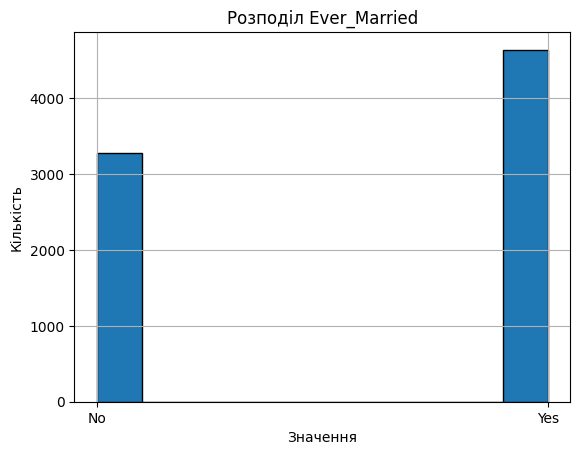

In [53]:
X['Ever_Married'].hist(bins=10, edgecolor='black')
plt.title('Розподіл Ever_Married')
plt.xlabel('Значення')
plt.ylabel('Кількість')
plt.grid(True)
plt.show()

як бачимо тут всього два значення, і якщо заповнити їх середнім чи, модою, це може вплинути на якість моделі, тому, заповнимо пусті значення "Unknown"

In [55]:
X['Ever_Married'] = X['Ever_Married'].fillna('Unknown')


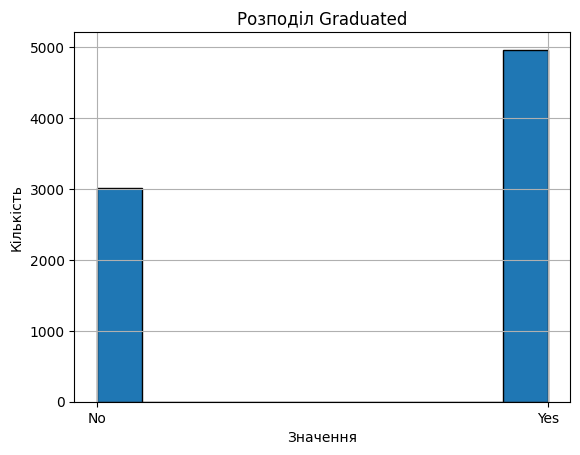

In [58]:
X['Graduated'].hist(bins=10, edgecolor='black')
plt.title('Розподіл Graduated')
plt.xlabel('Значення')
plt.ylabel('Кількість')
plt.grid(True)
plt.show()

In [59]:
X['Graduated'] = X['Graduated'].fillna('Unknown')

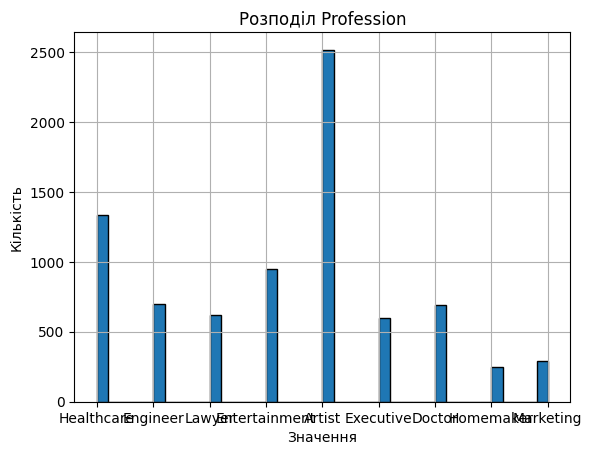

In [64]:
X['Profession'].hist(bins=40, edgecolor='black')
plt.title('Розподіл Profession')
plt.xlabel('Значення')
plt.ylabel('Кількість')
plt.grid(True)
plt.show()

In [65]:
X['Profession'] = X['Profession'].fillna('Unknown')


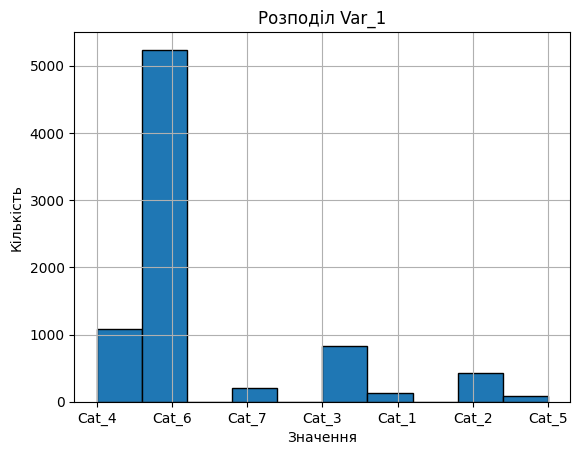

In [66]:
X['Var_1'].hist(bins=10, edgecolor='black')
plt.title('Розподіл Var_1')
plt.xlabel('Значення')
plt.ylabel('Кількість')
plt.grid(True)
plt.show()

In [68]:
X['Var_1'] = X['Var_1'].fillna('Unknown')

Всі пропущені значення були заповнені, тепер закодуємо категоріальні колонки, будемо використовувати OneHot encoder для колонок, які мають багато підкатегорій, а також для бінарних.\
Лише колонку Spending_Score закодуємо OrdinalEncode, бо колонка має порядок.


In [73]:
score_map = {'Low': 0, 'Average': 1, 'High': 2}
X['Spending_Score'] = X['Spending_Score'].map(score_map)


In [86]:
encoder = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')

In [87]:
X_categorical = X.select_dtypes('object')
X_encoded_categorical = encoder.fit_transform(X_categorical)
encoded_df = pd.DataFrame(X_encoded_categorical,columns=encoder.get_feature_names_out(X_categorical.columns),index=X.index)

In [88]:
encoded_df[:5]

,Gender_Male,Ever_Married_No,Ever_Married_Unknown,Ever_Married_Yes,Graduated_No,Graduated_Unknown,Graduated_Yes,Profession_Artist,Profession_Doctor,Profession_Engineer,...,Profession_Marketing,Profession_Unknown,Var_1_Cat_1,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7,Var_1_Unknown
ID,,,,,,,,,,,,,,,,,,,,,
462809,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
462643,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
466315,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
461735,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
462669,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [89]:
X_raw = X.copy()


Тепер зʼєднаємо закодований датафрейм з числовими колонками


In [ ]:
X_raw = X.copy()


In [91]:
X_numeric = X.select_dtypes(exclude='object')
X = pd.concat([X_numeric, encoded_df], axis=1) # Обробка по кожному рядку горизонтально це axis =1, axis = 0 по стовбцю вертикально

In [92]:
X

,Age,Work_Experience,Spending_Score,Family_Size,Gender_Male,Ever_Married_No,Ever_Married_Unknown,Ever_Married_Yes,Graduated_No,Graduated_Unknown,...,Profession_Marketing,Profession_Unknown,Var_1_Cat_1,Var_1_Cat_2,Var_1_Cat_3,Var_1_Cat_4,Var_1_Cat_5,Var_1_Cat_6,Var_1_Cat_7,Var_1_Unknown
ID,,,,,,,,,,,,,,,,,,,,,
462809,22.0,-0.451136,0,0.762698,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
462643,38.0,-0.451136,1,0.095802,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
466315,67.0,-0.451136,0,-1.237990,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
461735,67.0,-0.757410,2,-0.571094,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
462669,40.0,-0.451136,2,2.096491,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
464018,22.0,-0.757410,0,2.763387,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
464685,35.0,0.161413,0,0.762698,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
465406,33.0,-0.451136,0,-1.237990,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [93]:
X_train, X_val, y_train, y_val = train_test_split( X, y, train_size=0.8, random_state=42, stratify=y )


**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [103]:
X_num = X_train[['Age', 'Work_Experience', 'Family_Size']]
smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_num, y_train)

clf_smote = SVC(kernel='linear',probability=True)
clf_smote.fit(X_train_smote, y_train_smote)

SVC(kernel='linear', probability=True)

In [114]:
print("До SMOTE", X_train.shape)
print("Після SMOTE:", X_train_smote.shape)

До SMOTE (6454, 29)
Після SMOTE: (7256, 3)


In [112]:
smotetomek = SMOTETomek(random_state=0)
X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(X_num, y_train)

clf_smotetomek = SVC(kernel='linear',probability=True)
clf_smotetomek.fit(X_train_smotetomek, y_train_smotetomek)

SVC(kernel='linear', probability=True)

In [113]:
print("До SmoteTomek:", X_train.shape)
print("Після SmoteTomek:", X_num.shape)


До SmoteTomek: (6454, 29)
Після SmoteTomek: (6454, 3)


**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

In [108]:
clf_orig = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
clf_orig.fit(X_train, y_train)
y_pred_orig = clf_orig.predict(X_val)


In [110]:
X_val_num = X_val[['Age', 'Work_Experience', 'Family_Size']]
clf_smote = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
clf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = clf_smote.predict(X_val_num)


In [115]:
clf_smote_tomek = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
clf_smote_tomek.fit(X_train_smotetomek, y_train_smotetomek)
y_pred_smote_tomek = clf_smote_tomek.predict(X_val_num)


In [117]:
print("Оригінальні дані")
print(classification_report(y_val, y_pred_orig))

print("Після SMOTE")
print(classification_report(y_val, y_pred_smote))

print("Після SMOTE-Tomek")
print(classification_report(y_val, y_pred_smote_tomek))


Оригінальні дані
              precision    recall  f1-score   support

           A       0.42      0.45      0.44       394
           B       0.42      0.16      0.23       372
           C       0.49      0.64      0.55       394
           D       0.64      0.76      0.70       454

    accuracy                           0.52      1614
   macro avg       0.49      0.50      0.48      1614
weighted avg       0.50      0.52      0.49      1614

Після SMOTE
              precision    recall  f1-score   support

           A       0.32      0.29      0.31       394
           B       0.29      0.09      0.14       372
           C       0.36      0.42      0.39       394
           D       0.50      0.75      0.60       454

    accuracy                           0.41      1614
   macro avg       0.37      0.39      0.36      1614
weighted avg       0.37      0.41      0.37      1614

Після SMOTE-Tomek
              precision    recall  f1-score   support

           A       0.32     

Я обрала macro F1-score як основну метрику для порівняння моделей, тому що:
це задачa багатокласової класифікації.

macro F1 не залежить від дисбалансу класів — вона обчислює F1 окремо для кожного класу, а потім усереднює\
це дає чесну оцінку навіть для класів, які представлені меншою кількістю прикладів.

Модель на оригінальних даних (без балансування) показала найкращий результат — macro F1 = 0.48, а також вищий accuracy = 0.52.

Було використано лише 3 фічі (Age, Work_Experience, Family_Size) при SMOTE та Smotetomek, тому результати оригінальної моделі краще.